In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
diabetes=datasets.load_diabetes()
print(diabetes.data.shape)
print(diabetes.feature_names)

(442, 10)
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [3]:
#데이터프레임 (diabetes.data, column=diabetes.feature_names)
df=pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [4]:
diabetes_X = df['bmi'] #Series 형태
diabetes_X = df['bmi'].values #numpy의 배열형태로 변환
#머신러닝라이브러리에서 특성데이터는 2차원배열 형태
diabetes_X = df['bmi'].values.reshape(-1,1) #2차원 배열 형태 (열을 무조건 1로 맞추고 행의 개수는 열의 맞춰서 계산)

In [5]:
diabetes_X_train=diabetes_X[:-30] #뒤에서 30개를 제외한  모든데이터를 학습용 데이터셋
diabetes_X_test=diabetes_X[-30:] #마지막 30개의 데이터만 테스트용 데이터셋

In [8]:
diabetes_y_train=diabetes.target[:-30] #정답데이터도 뒤에서 30개를 제외한  모든데이터를 학습용 정답 데이터셋
diabetes_y_test=diabetes.target[-30:] #실제 정답 데이터셋

In [10]:
reg=linear_model.LinearRegression()
reg.fit(diabetes_X_train, diabetes_y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
# y=wx+b
print(reg.coef_)

[941.43097333]


In [12]:
# y=941.43 * BMI + 153.39
#새로운 BMI 값이 들어왔을 때, w,b를 이용해 계산 수행

#bmi(입력값)이 0일 때의 결과값
print(reg.intercept_)

153.39713623331644


In [13]:
y_pred=reg.predict(diabetes_X_test)
y_pred

array([233.80294072, 152.62808714, 159.73088683, 161.76025817,
       228.72951237, 220.61202701, 130.3050024 , 101.89380365,
       119.14346004, 168.86305786, 226.70014103, 116.09940303,
       163.78962951, 115.08471736, 121.17283138, 158.71620116,
       236.84699773, 122.18751705,  99.86443231, 124.21688839,
       205.39174197,  96.8203753 , 154.65745848, 131.31968807,
        83.62946159, 171.90711487, 138.42248776, 138.42248776,
       190.17145692,  84.64414726])

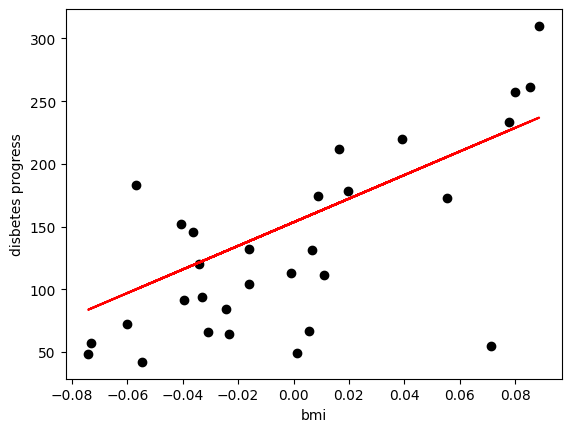

In [15]:
plt.scatter(diabetes_X_test, diabetes_y_test, color='black')
plt.plot(diabetes_X_test,y_pred, color='red')
plt.xlabel("bmi")
plt.ylabel('disbetes progress')
plt.show()

In [16]:
print(r2_score(diabetes_y_test, y_pred))

0.410920728135835


In [21]:
# 다변수 선형회귀
diabetes_X=df.values

In [22]:
diabetes_X_train=diabetes_X[:-30] #뒤에서 30개를 제외한  모든데이터를 학습용 데이터셋
diabetes_X_test=diabetes_X[-30:] #마지막 30개의 데이터만 테스트용 데이터셋

In [23]:
diabetes_y_train=diabetes.target[:-30] #정답데이터도 뒤에서 30개를 제외한  모든데이터를 학습용 정답 데이터셋
diabetes_y_test=diabetes.target[-30:] #실제 정답 데이터셋

In [24]:
reg=linear_model.LinearRegression()
reg.fit(diabetes_X_train, diabetes_y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
# y=wx+b
print(reg.coef_)

[  -1.16678648 -237.18123633  518.31283524  309.04204042 -763.10835067
  458.88378916   80.61107395  174.31796962  721.48087773   79.1952801 ]


In [26]:
# y=941.43 * BMI + 153.39
#새로운 BMI 값이 들어왔을 때, w,b를 이용해 계산 수행

#bmi(입력값)이 0일 때의 결과값
print(reg.intercept_)

153.05824267739402


In [27]:
y_pred=reg.predict(diabetes_X_test)
y_pred

array([234.03896413, 122.92309501, 166.34809083, 174.39099494,
       226.94554732, 151.82086149, 100.94255852,  83.08727035,
       143.1356399 , 192.67920648, 197.98468264, 154.38004377,
       173.16738102, 112.38622103, 164.19897972, 131.63491238,
       258.66636243, 101.41198791, 117.87093519, 123.53465033,
       219.51460279,  62.08880457, 133.09242505, 121.33016919,
        53.51560246, 193.12518234, 104.69419198, 123.69151485,
       211.27325419,  53.8691306 ])

In [29]:
# 당뇨병은 하나의 요인이 아닌 여러 복합적인 요인에 의해 결정된다
print(r2_score(diabetes_y_test, y_pred))

0.6454950067486565
